# 1. Entendimiento del problema
El gobierno Australiano quiere conocer cuanto puede ser el costo de el uso de corticoides y esteroides en el sistema de salud actual para preparar sus finanzas a futuro.

# 2. Enfoque analitico:
Vamos a construir un modelo de regresion basado en series de tiempo que permita estimar el costo de corticoides y esteroides con el menor MAE posible.  

# 3. Requerimiento de datos:
Se requiere los datos pasados del costo de los medicamentos.

# 4. Recolección de datos:

In [2]:
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset

In [13]:
data = fetch_dataset("h2o_exog")

╭─────────────────────────────────── h2o_exog ────────────────────────────────────╮
│ Description:                                                                    │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health   │
│ system had between 1991 and 2008. Two additional variables (exog_1, exog_2) are │
│ simulated.                                                                      │
│                                                                                 │
│ Source:                                                                         │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice (3rd      │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,                              │
│ https://github.com/robjhyndman/fpp3package, http://OTexts.com/fpp3.             │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/h2o_exog.csv                                                 │
│                                                                                 │
│ Shape: 195 rows x 3 columns                                                     │
╰─────────────────────────────────────────────────────────────────────────────────╯

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 195 entries, 1992-04-01 to 2008-06-01
Freq: MS
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       195 non-null    float64
 1   exog_1  195 non-null    float64
 2   exog_2  195 non-null    float64
dtypes: float64(3)
memory usage: 6.1 KB


# 5. Exploracion de datos
- Determinar la estacionaridad de la serie

In [20]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from skforecast.plot import set_dark_theme

set_dark_theme()

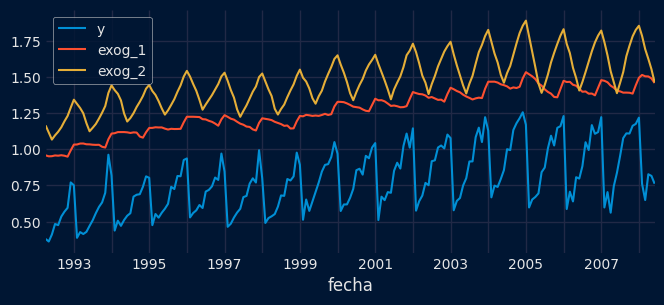

In [18]:
fig, ax = plt.subplots(figsize=(7, 3))
data.plot(ax=ax)
ax.legend()
plt.show()

TypeError: 'Axes' object is not subscriptable

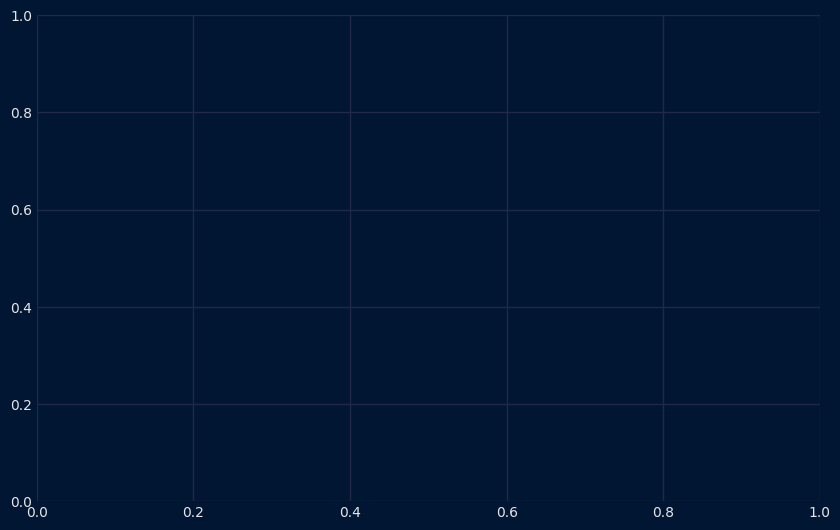

In [19]:
res_descompose = seasonal_decompose(data['y'], model='additive', extrapolate_trend='freq')

fig, ax = plt.subplots(figsize=(9, 6))
res_descompose.observed.plot(ax=ax[0])
ax[0].set_title('Serie original')

res_descompose.trend.plot(ax=ax[1])
ax[1].set_title('Componente Estacional')

res_descompose.seasonal.plot(ax=ax[2])
ax[2].set_title('Componente Estacional')

res_descompose.resid.plot(ax=ax[3])
ax[3].set_title('Componente Residual')

fig.tight_layout()
plt.show()

In [21]:
def test_estacionaridad(series):
    adfuller_result = adfuller(series)
    print(f'ADF Estadistico: {adfuller_result[0]}')
    print(f'Valor p: {adfuller_result[1]}')

In [22]:
test_estacionaridad(data['y'])

ADF Estadistico: -1.5180458060933468
Valor p: 0.5245662008648657


# 6. Preparacion de datos

- Diferenciar la serie
- Identificar su comportamiento estacional

ADF Estadistico: -3.272501193023123
Valor p: 0.016153320135666022


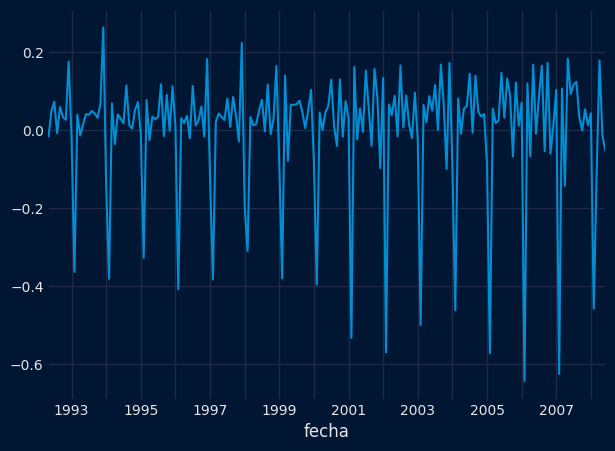

In [24]:
data_diff = data['y'].diff().dropna()
test_estacionaridad(data_diff)
data_diff.plot()
plt.show()

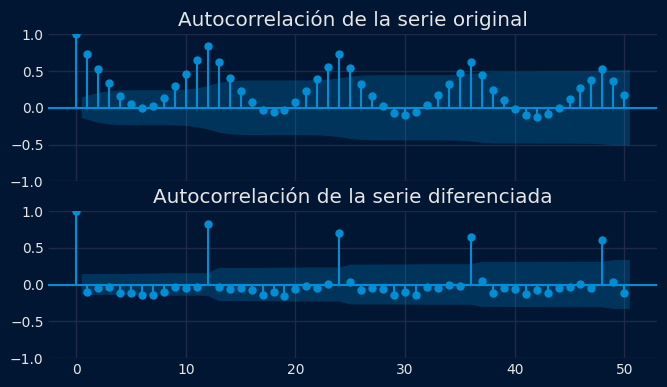

In [28]:
from statsmodels.graphics.tsaplots import plot_acf

# Grafico de autocorrelacion
fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)

plot_acf(data['y'], ax=ax[0], lags=50, alpha=0.05)
ax[0].set_title('Autocorrelación de la serie original')

plot_acf(data_diff, ax=ax[1], lags=50, alpha=0.05)
ax[1].set_title('Autocorrelación de la serie diferenciada')

plt.show()

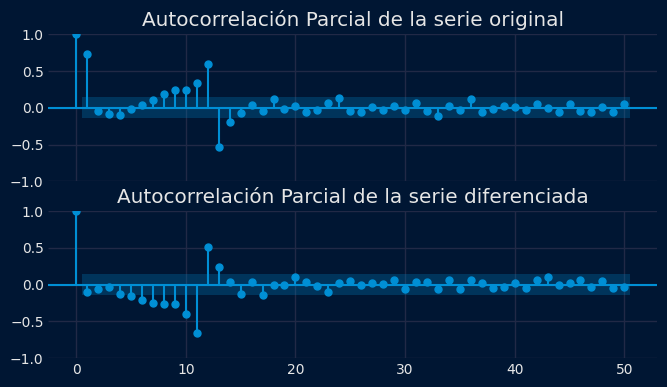

In [29]:
from statsmodels.graphics.tsaplots import plot_pacf

# Grafico de autocorrelacion
fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)

plot_pacf(data['y'], ax=ax[0], lags=50, alpha=0.05)
ax[0].set_title('Autocorrelación Parcial de la serie original')

plot_pacf(data_diff, ax=ax[1], lags=50, alpha=0.05)
ax[1].set_title('Autocorrelación Parcial de la serie diferenciada')

plt.show()